# Out-of-Sample Validation: Transition Firms as Never-Disclosers

Treat firms that transition from estimated → disclosed as if they **never disclosed**.
This forces the full pipeline (outcome model → propensity → tilt) to produce a blind
MNAR prediction for these firms at all times — including post-disclosure years where
we can compare against truth.

**Steps:**
1. Identify clean transition firms (same logic as notebook 06)
2. Save their actual disclosed values aside
3. Mask them: `co2_bool = 0`, `sc1_disclosed = NaN` for all years
4. Run the imputation + propensity + MC pipeline on the masked panel
5. Compare MNAR predictions vs actual disclosed values in an event-study plot

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Times New Roman', 'DejaVu Serif'],
    'font.size':         11,
    'axes.titlesize':    12,
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'grid.linewidth':    0.5,
    'figure.dpi':        150,
    'savefig.dpi':       300,
})

C_BLUE   = '#2166ac'
C_ORANGE = '#f4a020'
C_GREEN  = '#2ca02c'

FIG_DIR = Path('../data/outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load panel and identify transition firms

In [3]:
SPEC = dict(
    name              = "baseline",
    x_columns         = ["at", "year", "gind", "log_wti"],
    sector_col        = "gsector",
    iv_term           = "log_wti",
    n_mc              = 300,
    want_balanced     = True,
    filter_min_obs    = True,
    run_gam           = False,
    lm_base_x         = None,
    interaction_cutoff = None,
    interaction_col   = None,
    run_yearly_gamma  = False, #For yearly gamma plot
)

In [5]:
df = pd.read_parquet(
    "../data/processed/all_empiricals.parquet", engine="pyarrow"
)

if SPEC["filter_min_obs"] == True:
    col = 'gind'
    counts = df.groupby(col)["co2_bool"].agg(["sum", "count"])
    keep = counts[(counts["sum"] >= 20) & (counts["count"] - counts["sum"] >= 20)].index
    df = df[df[col].isin(keep)]
    print(f"Filtered to {df[col].nunique()} {col} groups ({len(df):,} obs)")

# Same industry filter as baseline notebook
keep_ind = df.groupby('gind')['co2_bool'].agg(['sum', 'count'])
keep_ind = keep_ind[(keep_ind['sum'] >= 5) & (keep_ind['count'] - keep_ind['sum'] >= 5)].index
df = df[df['gind'].isin(keep_ind)].copy()

# Create log-transformed IV columns
df["log_wti"] = np.log(df["wti_crude"])
df["log_gdp"] = np.log(df["gdp"])

df = df.sort_values(['gvkey', 'year'])
df['ppe_at'] = df['ppegt'] / df['at']

# predetermined exposure: each firm's earliest available PP&E intensity (first up-to-3 obs)
expo = df.groupby('gvkey')['ppe_at'].apply(lambda s: s.dropna().head(5).mean())
df['exposure'] = df['gvkey'].map(expo)

df = df.dropna(subset=['exposure'])
df.reset_index(drop=True, inplace=True)
# firms with no gross PP&E (mostly Financials/Real Estate) have ~no physical oil exposure:
lo,hi = df['exposure'].quantile([0.01,0.99])
print(f"exposure range before clip: [{df['exposure'].min():.2f}, {df['exposure'].max():.2f}]; clip to [{lo:.3f},{hi:.3f}]")
df['exposure'] = df['exposure'].clip(lo,hi)
df['exposure'] = (df['exposure'] - df['exposure'].mean()) / df['exposure'].std()
df['log_wti'] = df['exposure'] * df['log_wti']

Filtered to 60 gind groups (74,807 obs)
exposure range before clip: [0.00, 25.47]; clip to [0.000,2.345]


In [6]:
# Detect clean transition firms: exactly one estimated → disclosed switch, no reversals
check = df[df['year'] < 2023].copy().sort_values(['gvkey', 'year']).reset_index(drop=True)

check['type'] = 'missing'
check.loc[check['sc1_estimated'].notna(), 'type'] = 'estimated'
check.loc[check['sc1_disclosed'].notna(), 'type'] = 'disclosed'


def detect_strict_transition(group):
    group = group.sort_values('year').copy()
    types = group['type'].values
    transition_indices = [
        i for i in range(1, len(types))
        if types[i-1] == 'estimated' and types[i] == 'disclosed'
    ]
    if len(transition_indices) == 1:
        idx = transition_indices[0]
        before = types[:idx]
        after  = types[idx+1:]
        if (all(t in ['estimated', 'missing'] for t in before)
                and not any(t == 'estimated' for t in after)):
            row = group.iloc[[idx]].copy()
            row['t0_year'] = int(group.iloc[idx]['year'])
            return row
    return None


valid_transitions = (
    check
    .groupby('gvkey', group_keys=False)
    .apply(detect_strict_transition)
    .dropna(how='all')
    .reset_index(drop=True)
)

transition_gvkeys = set(valid_transitions['gvkey'].unique())
t0_map = valid_transitions[['gvkey', 't0_year']].copy()
t0_map['t0_year'] = t0_map['t0_year'].astype(int)

print(f"Found {len(transition_gvkeys)} clean transition firms")
print(f"Transition years: {valid_transitions['t0_year'].min():.0f} – {valid_transitions['t0_year'].max():.0f}")

Found 625 clean transition firms
Transition years: 2013 – 2022


In [7]:
n_before = len(transition_gvkeys)

# --- (a) Require continuous disclosure after t=0 ---
# A clean transition firm should stay disclosed every year after the switch.
# Drop firms that revert to 'missing' (no disclosed AND no estimated) post-switch.
drop_reversal = set()
for gvkey in transition_gvkeys:
    firm = check[check['gvkey'] == gvkey].sort_values('year')
    t0_yr = int(t0_map.loc[t0_map['gvkey'] == gvkey, 't0_year'].iloc[0])
    post = firm[firm['year'] > t0_yr]['type'].values
    # If any post-disclosure year reverts to missing or estimated, flag it
    if any(t != 'disclosed' for t in post):
        drop_reversal.add(gvkey)

# --- (b) Drop firms with extreme YoY swings in disclosed values ---
# A >5x jump or drop between consecutive disclosed years is likely a data error.
drop_yoy = set()
for gvkey in transition_gvkeys - drop_reversal:
    firm = df[(df['gvkey'] == gvkey) & (df['sc1_disclosed'].notna())].sort_values('year')
    vals = firm['sc1_disclosed'].values
    if len(vals) >= 2:
        ratios = vals[1:] / np.where(vals[:-1] > 0, vals[:-1], np.nan)
        ratios = ratios[np.isfinite(ratios)]
        if any((ratios > 5) | (ratios < 0.1)):
            drop_yoy.add(gvkey)

# Apply filters
transition_gvkeys -= drop_reversal | drop_yoy
t0_map = t0_map[t0_map['gvkey'].isin(transition_gvkeys)].copy()

print(f"Outlier filtering:")
print(f"  Dropped {len(drop_reversal)} firms with disclosure reversals (disclosed → missing)")
print(f"  Dropped {len(drop_yoy)} firms with extreme YoY swings (>10×)")

Outlier filtering:
  Dropped 4 firms with disclosure reversals (disclosed → missing)
  Dropped 18 firms with extreme YoY swings (>10×)


## 2. Mask transition firms as never-disclosers

Save their actual disclosed values, then set `co2_bool = 0` and `sc1_disclosed = NaN`
for all their observations. The outcome model will now impute for them based on
fundamentals alone, and the propensity model will treat them as non-disclosers.

In [8]:
# Save ground truth for later comparison
truth = df[df['gvkey'].isin(transition_gvkeys)][['gvkey', 'year', 'sc1_disclosed', 'sc1_estimated']].copy()
truth = truth.rename(columns={'sc1_disclosed': 'sc1_disclosed_actual', 'sc1_estimated': 'sc1_estimated_actual'})

# Mask transition firms
df_masked = df.copy()
mask = df_masked['gvkey'].isin(transition_gvkeys)

n_disclosed_before = df_masked.loc[mask, 'sc1_disclosed'].notna().sum()
df_masked.loc[mask, 'co2_bool'] = 0
df_masked.loc[mask, 'sc1_disclosed'] = np.nan

print(f"Masked {mask.sum():,} firm-year observations ({len(transition_gvkeys)} firms)")
print(f"  - Zeroed out {n_disclosed_before:,} disclosed values")
print(f"  - Disclosers after masking: {df_masked['co2_bool'].sum():,.0f} (was {df['co2_bool'].sum():,.0f})")

Masked 6,847 firm-year observations (603 firms)
  - Zeroed out 2,236 disclosed values
  - Disclosers after masking: 4,458 (was 6,694)


## 3. Run imputation + MC pipeline on masked panel

In [9]:
from corporate_omissions.models.ols_lognormal_imputer import OLSLogNormalImputer

imp = OLSLogNormalImputer()
out = imp.fit_simulate(
    df_masked,
    x_columns=["at", "year", "gind", "log_wti"],
    n_draws=10,
    draws_wide=True,
    quantiles=(0.05, 0.50, 0.95),
    print_summary=True,
)
df_full = out["df_full"]

                            OLS Regression Results                            
Dep. Variable:                 _log_y   R-squared:                       0.820
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     280.9
Date:                Fri, 10 Jul 2026   Prob (F-statistic):               0.00
Time:                        14:40:32   Log-Likelihood:                -7324.8
No. Observations:                4458   AIC:                         1.479e+04
Df Residuals:                    4386   BIC:                         1.525e+04
Df Model:                          71                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             3.3759      0.213     15.835

In [20]:
# Source - https://stackoverflow.com/a/14463362
# Posted by Mike, modified by community. See post 'Timeline' for change history
# Retrieved 2026-07-10, License - CC BY-SA 4.0

import warnings
warnings.filterwarnings("ignore")

In [22]:
from corporate_omissions.simulations.mc_simulator import run_mc

N_MC = 30
X_COLUMNS = ["at", "year", "gind", "log_wti"]
Y_COMPLETE = "sc1_disclosed_complete"

SIM_COMMON = (
    "sc1_disclosed_complete", "propensity", "tilt", "sc1_ours", "sc1_adj",
    "sc1_disclosed_imp_seed", "sc1_disclosed_imp_draw",
    "sc1_disclosed_imp_draw_1", "sc1_disclosed_imp_draw_2", "sc1_disclosed_imp_draw_3",
    "sc1_disclosed_imp_draw_4", "sc1_disclosed_imp_draw_5", "sc1_disclosed_imp_draw_6",
    "sc1_disclosed_imp_draw_7", "sc1_disclosed_imp_draw_8", "sc1_disclosed_imp_draw_9",
    "sc1_disclosed_imp_draw_10",
)
SIM_COLS_LM  = ("tilt_absolute",) + SIM_COMMON
SIM_COLS_GAM = ("tilt_semiparametric",) + SIM_COMMON

mc_out = run_mc(
    df_raw=df_full,
    x_columns=X_COLUMNS,
    y_complete=Y_COMPLETE,
    n_mc=N_MC,
    mc_seeds=list(range(1, N_MC + 1)),
    want_balanced=True,
    balance_seed=0,
    gam_iv_spec=["gdp", "wti_crude"],
    lm_iv_spec=["gdp", "wti_crude"],
    store_pdep=False,
    simulated_cols_lm=SIM_COLS_LM,
    simulated_cols_gam=SIM_COLS_GAM,
    log_transform=False,
    sector_col="gind"
)

df_lm_avg  = mc_out["df_lm_avg"]
df_gam_avg = mc_out["df_gam_avg"]
print(f"MC done. LM avg: {df_lm_avg.shape}, GAM avg: {df_gam_avg.shape}")

did not converge
MC done. LM avg: (66855, 47), GAM avg: (66855, 47)


## 4. Build event-study panel and compare against truth

For transition firms, merge the blind MNAR prediction (`sc1_ours` from the masked run)
against the actual disclosed values we saved earlier. Align on event time relative to
first disclosure ($t=0$).

In [23]:
# Extract transition firms from the masked MC results (using GAM; swap to df_lm_avg if preferred)
oos = df_lm_avg[df_lm_avg['gvkey'].isin(transition_gvkeys)].copy()

# Merge ground truth
oos = oos.merge(truth, on=['gvkey', 'year'], how='left')

# Merge event time
oos = oos.merge(t0_map, on='gvkey', how='left')
oos['etime'] = oos['year'].astype(int) - oos['t0_year']
oos = oos[oos['etime'].between(-4, 4)].copy()

print(f"OOS event panel: {len(oos):,} rows, {oos['gvkey'].nunique()} firms")
print(oos.groupby('etime')['gvkey'].count().rename('n_obs'))

OOS event panel: 4,427 rows, 603 firms
etime
-4    558
-3    575
-2    588
-1    602
 0    603
 1    601
 2    436
 3    288
 4    176
Name: n_obs, dtype: int64


In [24]:
# Compute log emissions for each series
oos['log_mnar']      = np.log(oos['sc1_ours'].clip(lower=1))
oos['log_trucost']   = np.log(oos['sc1_estimated_actual'].clip(lower=1))
oos['log_disclosed'] = np.log(oos['sc1_disclosed_actual'].clip(lower=1))

# Aggregate by event time
def agg_series(col):
    valid = oos[oos[col].notna()].groupby('etime')[col]
    return pd.DataFrame({
        'mean': valid.mean(),
        'p25':  valid.quantile(0.25),
        'p75':  valid.quantile(0.75),
        'n':    valid.count(),
    })

a_mnar = agg_series('log_mnar')
a_truc = agg_series('log_trucost')
a_disc = agg_series('log_disclosed')

print("Mean log emissions by event time:")
print(pd.DataFrame({
    'MNAR (blind)': a_mnar['mean'],
    'Trucost':      a_truc['mean'],
    'Disclosed':    a_disc['mean'],
    'N':            a_mnar['n'],
}).round(3))

Mean log emissions by event time:
       MNAR (blind)  Trucost  Disclosed    N
etime                                       
-4           10.652   10.719        NaN  558
-3           10.686   10.817        NaN  575
-2           10.775   10.884        NaN  588
-1           10.905   10.958        NaN  602
 0           10.920      NaN     10.343  603
 1           10.925    9.379     10.461  601
 2           11.328    9.223     10.898  436
 3           11.761   10.304     11.409  288
 4           12.175   10.692     11.692  176


## 5. Event-study plot

The MNAR line now runs through the entire window — it is a **blind** prediction
for all event times, since these firms were masked as never-disclosers.
The green disclosed line from $t=0$ onward is truth we can compare against.

Saved fig_oos_transition_validation


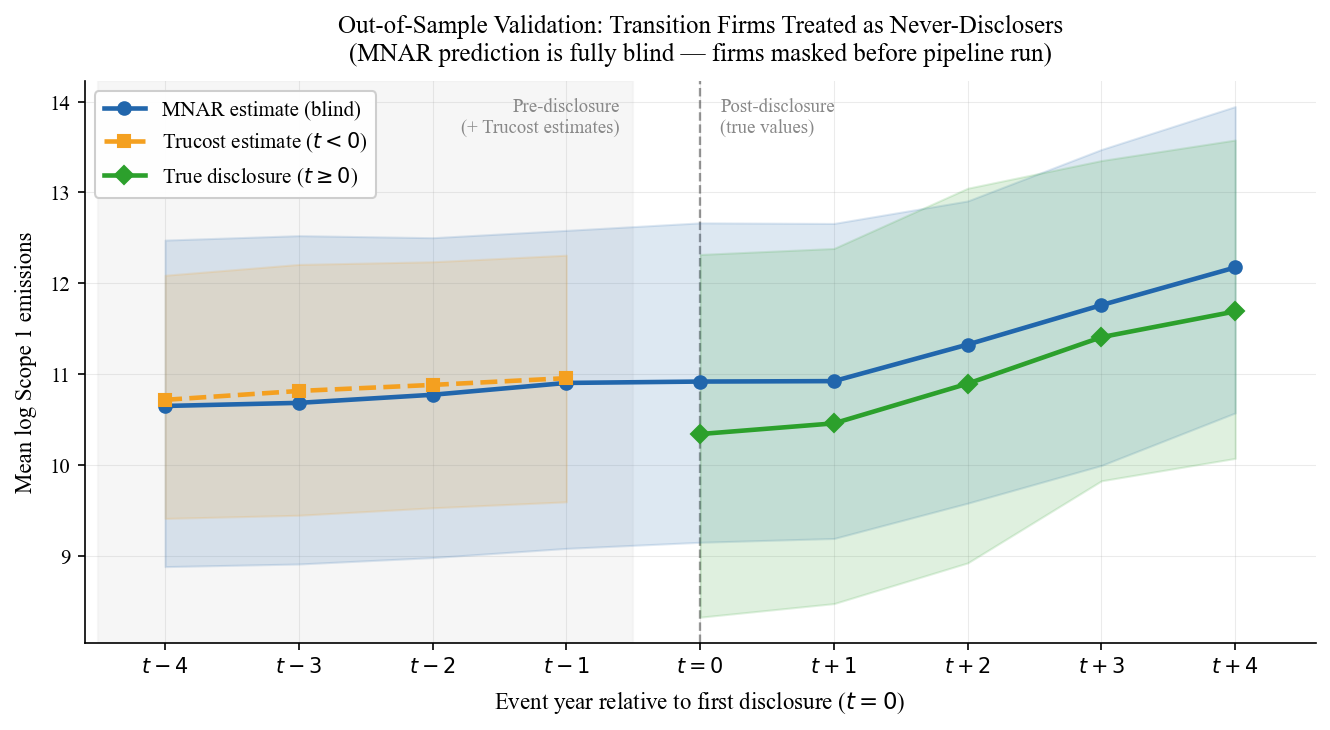

In [25]:
etimes = sorted(oos['etime'].unique())

fig, ax = plt.subplots(figsize=(9, 5))

# Background
ax.axvspan(min(etimes) - 0.5, -0.5, color='#f0f0f0', alpha=0.6, zorder=0)
ax.axvline(0, color='#333333', linewidth=1.1, linestyle='--', alpha=0.5)
ax.text(-0.6, 0.97, 'Pre-disclosure\n(+ Trucost estimates)',
        ha='right', va='top', fontsize=9, color='#888888',
        transform=ax.get_xaxis_transform())
ax.text(0.15, 0.97, 'Post-disclosure\n(true values)',
        ha='left', va='top', fontsize=9, color='#888888',
        transform=ax.get_xaxis_transform())

# MNAR blind prediction — runs across the full window
ax.fill_between(a_mnar.index, a_mnar['p25'], a_mnar['p75'],
                color=C_BLUE, alpha=0.15, zorder=2)
ax.plot(a_mnar.index, a_mnar['mean'],
        color=C_BLUE, linewidth=2.2, marker='o', markersize=6,
        label='MNAR estimate (blind)', zorder=4)

# Trucost (available pre-disclosure only for these firms)
tv = a_truc[(a_truc['n'] > 10) & (a_truc.index < 0)]
if len(tv):
    ax.fill_between(tv.index, tv['p25'], tv['p75'],
                    color=C_ORANGE, alpha=0.15, zorder=2)
    ax.plot(tv.index, tv['mean'],
            color=C_ORANGE, linewidth=2.2, marker='s', markersize=6,
            linestyle='--', label='Trucost estimate ($t < 0$)', zorder=4)

# Actual disclosed (available from t=0 onward)
dv = a_disc[(a_disc['n'] > 10) & (a_disc.index >= 0)]
if len(dv):
    ax.fill_between(dv.index, dv['p25'], dv['p75'],
                    color=C_GREEN, alpha=0.15, zorder=2)
    ax.plot(dv.index, dv['mean'],
            color=C_GREEN, linewidth=2.2, marker='D', markersize=6,
            label='True disclosure ($t \\geq 0$)', zorder=5)

ax.set_xlabel('Event year relative to first disclosure ($t = 0$)', labelpad=6)
ax.set_ylabel('Mean log Scope 1 emissions', labelpad=6)
ax.set_title(
    'Out-of-Sample Validation: Transition Firms Treated as Never-Disclosers\n'
    '(MNAR prediction is fully blind — firms masked before pipeline run)',
    pad=10,
)
ax.set_xticks(etimes)
ax.set_xticklabels(
    ['$t{:+d}$'.format(e) if e != 0 else '$t=0$' for e in etimes]
)
ax.set_xlim(min(etimes) - 0.6, max(etimes) + 0.6)
ax.legend(loc='upper left', framealpha=0.95, edgecolor='#cccccc')

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig_oos_transition_validation.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig_oos_transition_validation.png', dpi=300, bbox_inches='tight')
print('Saved fig_oos_transition_validation')
plt.show()

In [26]:
# Anchor: each firm's actual first-disclosed value at t=0
anchor = (
    oos[oos['etime'] == 0]
    .groupby('gvkey')['sc1_disclosed_actual']
    .mean()
    .rename('sc1_disc_t0')
    .reset_index()
)
anchor = anchor[anchor['sc1_disc_t0'] > 0]

oos_norm = oos.merge(anchor, on='gvkey', how='inner')

# Ratios: prediction / first disclosed value
oos_norm['r_mnar']    = oos_norm['sc1_ours']             / oos_norm['sc1_disc_t0']
oos_norm['r_trucost'] = oos_norm['sc1_estimated_actual']  / oos_norm['sc1_disc_t0']
oos_norm['r_disc']    = oos_norm['sc1_disclosed_actual']  / oos_norm['sc1_disc_t0']

# Winsorize at 2.5% / 97.5%
for col in ['r_mnar', 'r_trucost', 'r_disc']:
    lo, hi = oos_norm[col].quantile([0.025, 0.975])
    oos_norm[col] = oos_norm[col].clip(lo, hi)

def agg_ratio(col):
    valid = oos_norm[oos_norm[col].notna()].groupby('etime')[col]
    return pd.DataFrame({
        'median': valid.median(),
        'p25':    valid.quantile(0.25),
        'p75':    valid.quantile(0.75),
        'n':      valid.count(),
    })

r_mnar = agg_ratio('r_mnar')
r_truc = agg_ratio('r_trucost')
r_disc = agg_ratio('r_disc')

print("Median ratio to first disclosed value:")
print(pd.DataFrame({
    'MNAR (blind)': r_mnar['median'],
    'Trucost':      r_truc['median'],
    'Disclosed':    r_disc['median'],
    'N':            r_mnar['n'],
}).round(3))

Median ratio to first disclosed value:
       MNAR (blind)  Trucost  Disclosed    N
etime                                       
-4            1.431    1.406        NaN  558
-3            1.499    1.428        NaN  575
-2            1.625    1.533        NaN  588
-1            1.716    1.510        NaN  602
 0            1.751      NaN      1.000  603
 1            1.793    1.012      1.013  601
 2            1.736    1.002      1.023  436
 3            1.651    0.955      1.024  288
 4            1.696    0.906      1.079  176


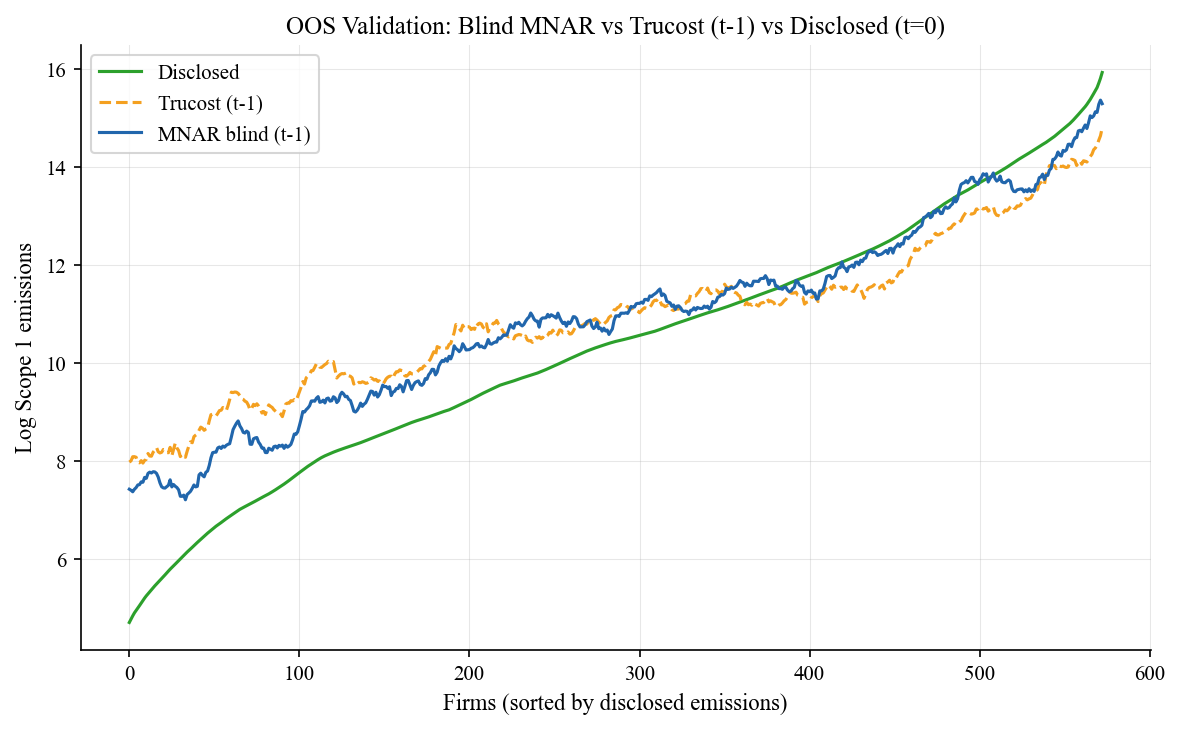

In [27]:
# At t=0: sort firms by actual disclosed value, compare smoothed log emissions
# Trucost and MNAR (blind) come from t-1 (same approach as notebook 06)
t0 = oos[oos['etime'] == 0][['gvkey', 'sc1_disclosed_actual']].copy()
t0 = t0[t0['sc1_disclosed_actual'].notna() & (t0['sc1_disclosed_actual'] > 0)]

tm1 = oos[oos['etime'] == -1][['gvkey', 'sc1_ours', 'sc1_estimated_actual']].copy()
tm1 = tm1.rename(columns={'sc1_ours': 'sc1_ours_t-1', 'sc1_estimated_actual': 'sc1_estimated_t-1'})

t0 = t0.merge(tm1, on='gvkey', how='inner')
t0 = t0.sort_values(by='sc1_disclosed_actual').reset_index(drop=True)

window = 30

def smooth(arr):
    return np.convolve(arr, np.ones(window)/window, mode='valid')

plt.figure(figsize=(8, 5))
plt.plot(smooth(np.log(t0['sc1_disclosed_actual'])), label='Disclosed', color=C_GREEN)
plt.plot(smooth(np.log(t0['sc1_estimated_t-1'].clip(lower=1))), label='Trucost (t-1)', color=C_ORANGE, linestyle='--')
plt.plot(smooth(np.log(t0['sc1_ours_t-1'].clip(lower=1))), label='MNAR blind (t-1)', color=C_BLUE)

plt.xlabel("Firms (sorted by disclosed emissions)")
plt.ylabel("Log Scope 1 emissions")
plt.title("OOS Validation: Blind MNAR vs Trucost (t-1) vs Disclosed (t=0)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_oos_firm_sorted.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
# Anchor: each firm's actual disclosed value at t=0
anchor = (
    oos[oos['etime'] == 0]
    .groupby('gvkey')['sc1_disclosed_actual']
    .mean()
    .rename('sc1_disc_t0')
    .reset_index()
)
anchor = anchor[anchor['sc1_disc_t0'] > 0]

oos_norm = oos.merge(anchor, on='gvkey', how='inner')

# Normalize: divide by own t=0 disclosed value
oos_norm['r_mnar']    = oos_norm['sc1_ours']            / oos_norm['sc1_disc_t0']
oos_norm['r_trucost'] = oos_norm['sc1_estimated_actual'] / oos_norm['sc1_disc_t0']
oos_norm['r_disc']    = oos_norm['sc1_disclosed_actual'] / oos_norm['sc1_disc_t0']

# Aggregate medians by event time
def agg_median(col):
    valid = oos_norm[oos_norm[col].notna()].groupby('etime')[col]
    return pd.DataFrame({
        'median': valid.median(),
        'p25':    valid.quantile(0.25),
        'p75':    valid.quantile(0.75),
        'n':      valid.count(),
    })

r_mnar = agg_median('r_mnar')
r_truc = agg_median('r_trucost')
r_disc = agg_median('r_disc')

print("Median ratio (emissions / own disclosed at t=0):")
print(pd.DataFrame({
    'MNAR (blind)': r_mnar['median'],
    'Trucost':      r_truc['median'],
    'Disclosed':    r_disc['median'],
    'N':            r_mnar['n'],
}).round(3))

Median ratio (emissions / own disclosed at t=0):
       MNAR (blind)  Trucost  Disclosed    N
etime                                       
-4            1.431    1.406        NaN  558
-3            1.499    1.428        NaN  575
-2            1.625    1.533        NaN  588
-1            1.716    1.510        NaN  602
 0            1.751      NaN      1.000  603
 1            1.793    1.012      1.013  601
 2            1.736    1.002      1.023  436
 3            1.651    0.955      1.024  288
 4            1.696    0.906      1.079  176


Saved fig_oos_normalized_median


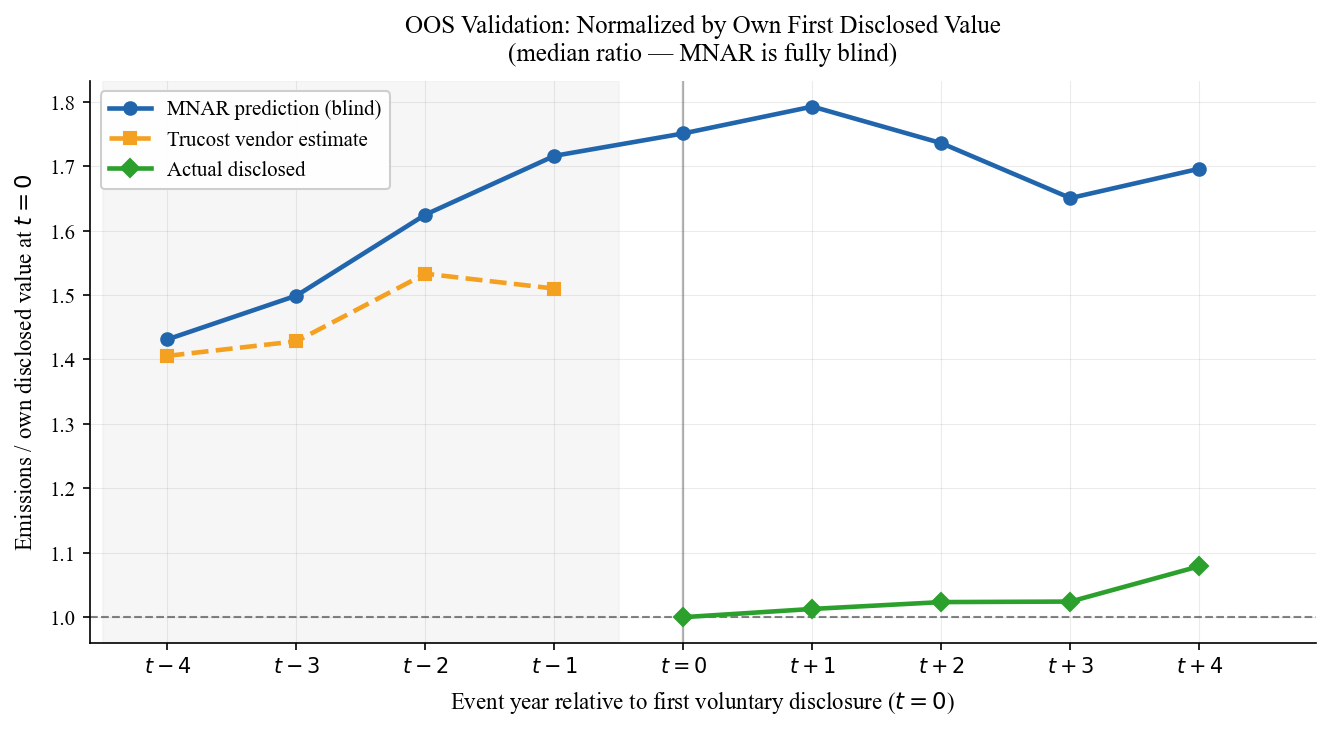

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.axvspan(min(etimes) - 0.5, -0.5, color='#f0f0f0', alpha=0.6, zorder=0)
ax.axhline(1.0, color='#333333', linewidth=1.0, linestyle='--', alpha=0.6)
ax.axvline(0, color='#333333', linewidth=1.1, linestyle='-', alpha=0.35)

# MNAR (blind) — full window, median
ax.plot(r_mnar.index, r_mnar['median'],
        color=C_BLUE, linewidth=2.2, marker='o', markersize=6,
        label='MNAR prediction (blind)', zorder=4)

# Trucost (pre-disclosure)
tv = r_truc[(r_truc['n'] > 10) & (r_truc.index < 0)]
if len(tv):
    ax.plot(tv.index, tv['median'],
            color=C_ORANGE, linewidth=2.2, marker='s', markersize=6,
            linestyle='--', label='Trucost vendor estimate', zorder=4)

# Actual disclosed (from t=0)
dv = r_disc[(r_disc['n'] > 10) & (r_disc.index >= 0)]
if len(dv):
    ax.plot(dv.index, dv['median'],
            color=C_GREEN, linewidth=2.2, marker='D', markersize=6,
            label='Actual disclosed', zorder=5)

ax.set_xlabel('Event year relative to first voluntary disclosure ($t = 0$)', labelpad=6)
ax.set_ylabel('Emissions / own disclosed value at $t=0$', labelpad=6)
ax.set_title(
    'OOS Validation: Normalized by Own First Disclosed Value\n'
    '(median ratio — MNAR is fully blind)',
    pad=10,
)
ax.set_xticks(etimes)
ax.set_xticklabels(
    ['$t{:+d}$'.format(e) if e != 0 else '$t=0$' for e in etimes]
)
ax.set_xlim(min(etimes) - 0.6, max(etimes) + 0.9)
ax.legend(loc='upper left', framealpha=0.95, edgecolor='#cccccc')

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig_oos_normalized_median.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig_oos_normalized_median.png', dpi=300, bbox_inches='tight')
print('Saved fig_oos_normalized_median')
plt.show()

Saved fig_oos_by_quartile


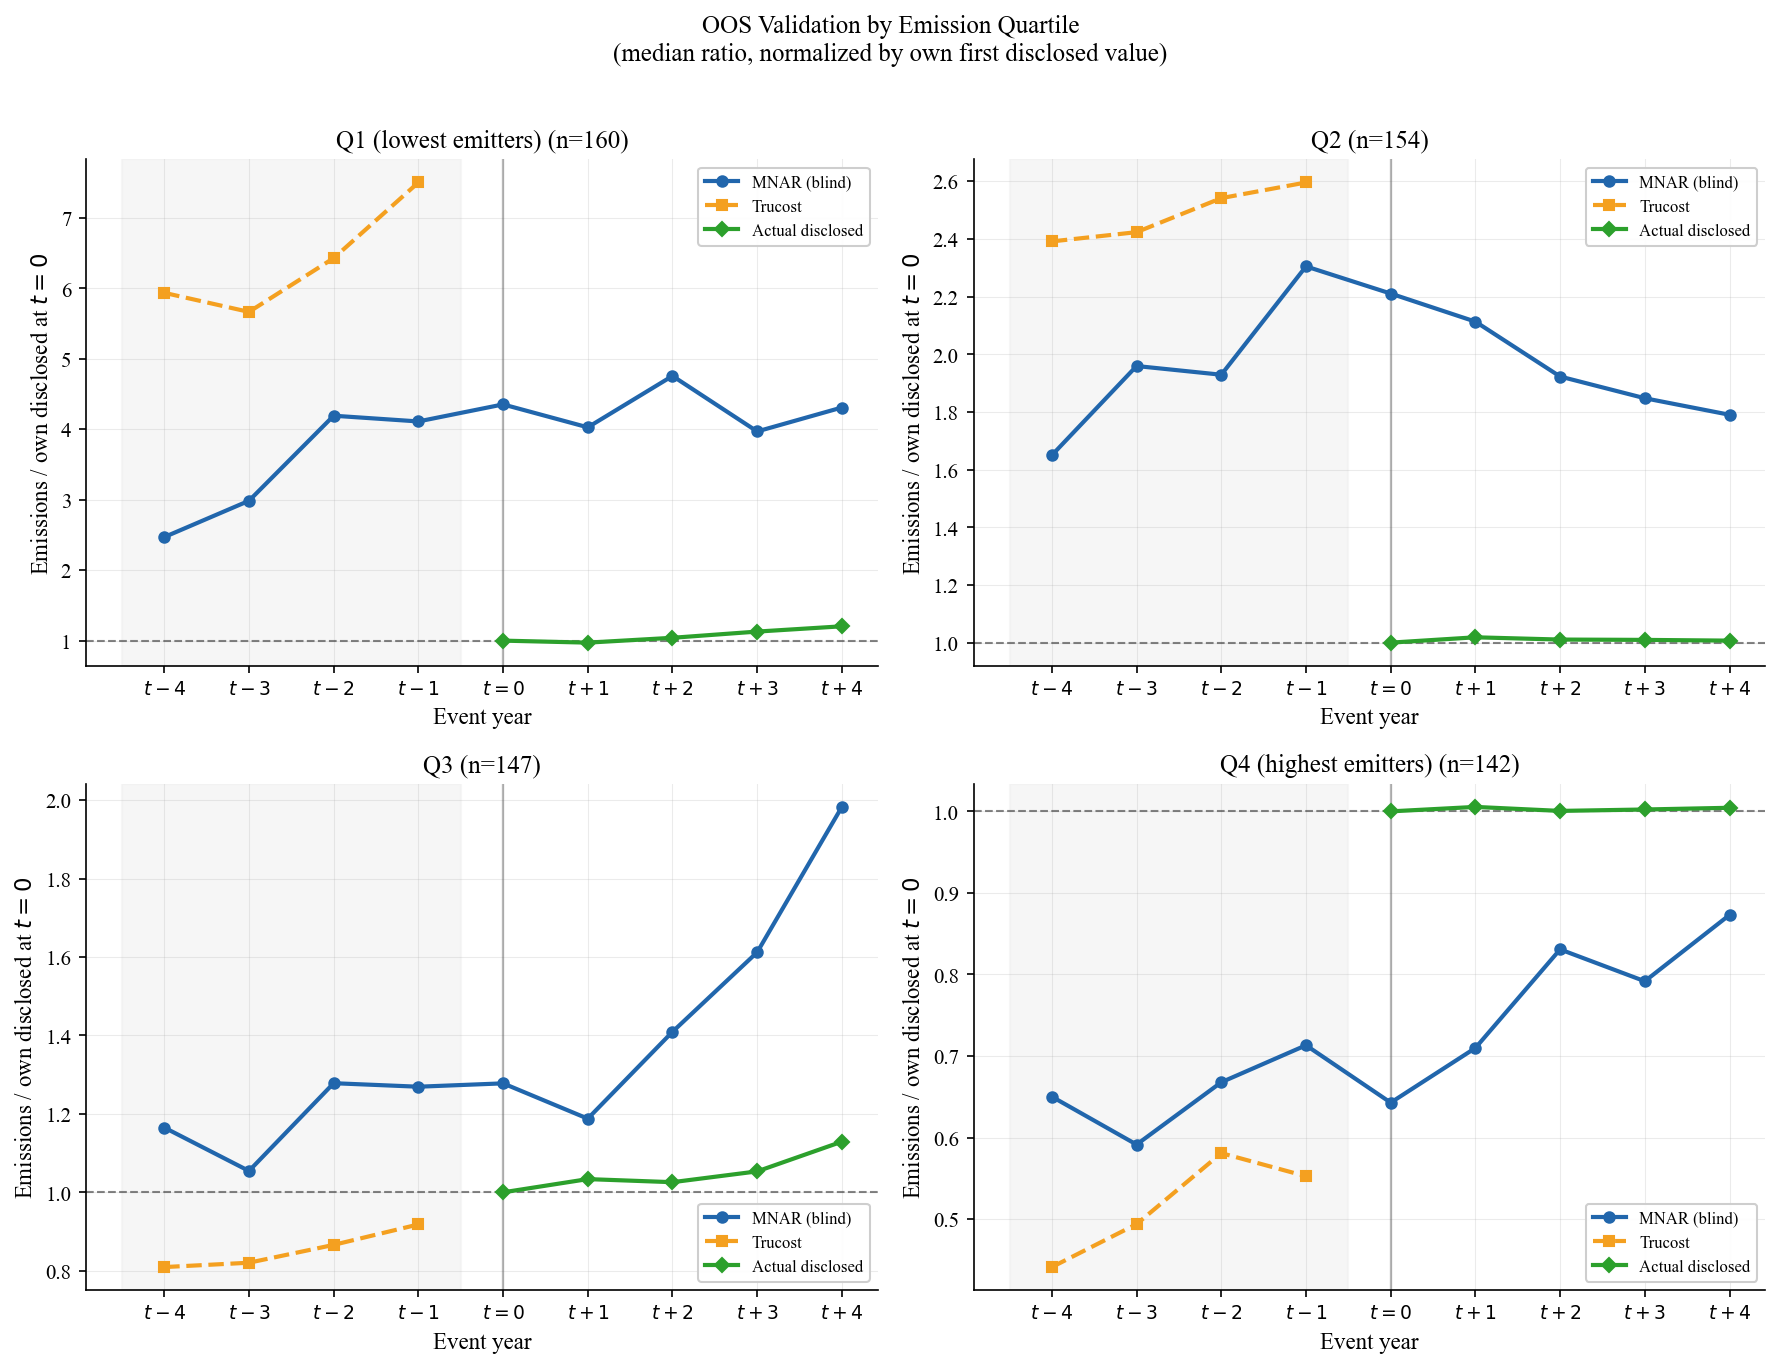

In [30]:
# Split firms into quantiles by disclosed emissions at t=0
n_quantiles = 4
oos_norm['q'] = pd.qcut(oos_norm['sc1_disc_t0'], n_quantiles, labels=False)

q_labels = {0: 'Q1 (lowest emitters)', 1: 'Q2', 2: 'Q3', 3: 'Q4 (highest emitters)'}

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=False)

for q, ax in zip(range(n_quantiles), axes.flat):
    sub = oos_norm[oos_norm['q'] == q]

    rm = sub.groupby('etime')['r_mnar'].median()
    rt = sub[sub['r_trucost'].notna()].groupby('etime')['r_trucost'].median()
    rd = sub[sub['r_disc'].notna()].groupby('etime')['r_disc'].median()

    ax.axvspan(min(etimes) - 0.5, -0.5, color='#f0f0f0', alpha=0.6, zorder=0)
    ax.axhline(1.0, color='#333333', linewidth=1.0, linestyle='--', alpha=0.6)
    ax.axvline(0, color='#333333', linewidth=1.1, linestyle='-', alpha=0.35)

    ax.plot(rm.index, rm.values,
            color=C_BLUE, linewidth=2.0, marker='o', markersize=5,
            label='MNAR (blind)')

    rt_pre = rt[rt.index < 0]
    if len(rt_pre):
        ax.plot(rt_pre.index, rt_pre.values,
                color=C_ORANGE, linewidth=2.0, marker='s', markersize=5,
                linestyle='--', label='Trucost')

    rd_post = rd[rd.index >= 0]
    if len(rd_post):
        ax.plot(rd_post.index, rd_post.values,
                color=C_GREEN, linewidth=2.0, marker='D', markersize=5,
                label='Actual disclosed')

    n_firms = sub['gvkey'].nunique()
    ax.set_title(f'{q_labels[q]} (n={n_firms})', pad=6)
    ax.set_xticks(etimes)
    ax.set_xticklabels(
        ['$t{:+d}$'.format(e) if e != 0 else '$t=0$' for e in etimes],
        fontsize=9,
    )
    ax.set_xlabel('Event year', labelpad=4)
    ax.set_ylabel('Emissions / own disclosed at $t=0$', labelpad=4)
    ax.legend(fontsize=8, framealpha=0.95, edgecolor='#cccccc')

fig.suptitle(
    'OOS Validation by Emission Quartile\n'
    '(median ratio, normalized by own first disclosed value)',
    fontsize=12, y=1.01,
)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig_oos_by_quartile.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIG_DIR / 'fig_oos_by_quartile.png', dpi=300, bbox_inches='tight')
print('Saved fig_oos_by_quartile')
plt.show()